# 一、入门学习

## 学习LSTM网络初始知识

导入库

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

生成随机实验序列

In [2]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [3]:
# 生成示例数据
np.random.seed(42)
time_steps = np.arange(0, 1000, 0.1)
data = np.sin(time_steps * 0.1) + np.random.normal(0, 0.1, len(time_steps))

# 数据预处理
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))


In [4]:
# 创建序列数据
SEQ_LENGTH = 50
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# 转换为PyTorch张量
X_tensor = torch.FloatTensor(X).view(-1, SEQ_LENGTH, 1)
y_tensor = torch.FloatTensor(y)

In [5]:
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor.numpy(), y_tensor.numpy(), test_size=0.2, shuffle=False
)
X_train = torch.FloatTensor(X_train).view(-1, SEQ_LENGTH, 1)
X_test = torch.FloatTensor(X_test).view(-1, SEQ_LENGTH, 1)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

定义LSTM模型

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(
            0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(
            0), self.hidden_size).to(x.device)

        # LSTM前向传播
        out, _ = self.lstm(x, (h0, c0))

        # 取最后一个时间步
        out = out[:, -1, :]

        # 全连接层
        out = self.fc(out)
        return out

In [7]:
# 测试cuda可行性
print("PyTorch 版本：", torch.__version__)
print("CUDA 是否可用：", torch.cuda.is_available())
print("CUDA 版本：", torch.version.cuda)

PyTorch 版本： 2.10.0.dev20251124+cu128
CUDA 是否可用： True
CUDA 版本： 12.8


训练模型

In [8]:
# 初始化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel().to(device)

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 100
batch_size = 32

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    # 批量训练
    for i in range(0, len(X_train), batch_size):
        batch_x = X_train[i:i+batch_size].to(device)
        batch_y = y_train[i:i+batch_size].to(device)

        # 前向传播
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 20 == 0:
        print(
            f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(X_train):.6f}')

Epoch [20/100], Loss: 0.000074
Epoch [40/100], Loss: 0.000065
Epoch [60/100], Loss: 0.000066
Epoch [80/100], Loss: 0.000073
Epoch [100/100], Loss: 0.000064


测试

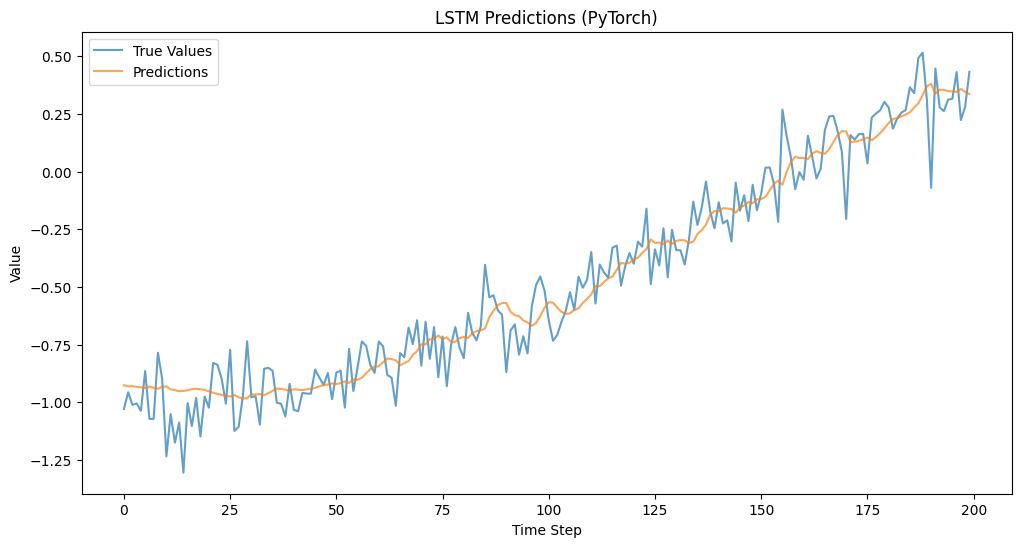

In [9]:
# 预测
model.eval()
with torch.no_grad():
    train_predict = model(X_train.to(device))
    test_predict = model(X_test.to(device))

# 反标准化
train_predict = scaler.inverse_transform(train_predict.cpu().numpy())
test_predict = scaler.inverse_transform(test_predict.cpu().numpy())
y_train_orig = scaler.inverse_transform(y_train.numpy())
y_test_orig = scaler.inverse_transform(y_test.numpy())

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig[:200], label='True Values', alpha=0.7)
plt.plot(test_predict[:200], label='Predictions', alpha=0.7)
plt.title('LSTM Predictions (PyTorch)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()